⏳ Streaming and downloading the MNIST handwritten digit database...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✔️ Loaded 60000 training images and 10000 testing images.
   -> Original image structural shape: (28, 28) pixels

⚙️ Designing Multi-Layer Perceptron (MLP) Neural Network Blueprint...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten_784 (Flatten)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1_ReLU (Dense)     │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularization_Dropout_20pct    │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2_ReLU (Dense)     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Probability_Softmax      │ (None, 10)             │           650 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Commencing model training and backpropagation tuning...
Epoch 1/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8939 - loss: 0.3624 - val_accuracy: 0.9549 - val_loss: 0.1541
Epoch 2/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9518 - loss: 0.1620 - val_accuracy: 0.9652 - val_loss: 0.1161
Epoch 3/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9635 - loss: 0.1213 - val_accuracy: 0.9697 - val_loss: 0.1013
Epoch 4/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9705 - loss: 0.0970 - val_accuracy: 0.9687 - val_loss: 0.1031
Epoch 5/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9744 - loss: 0.0816 - val_accuracy: 0.9737 - val_loss: 0.0903
Epoch 6/6
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9772 - loss: 0.0710 - val_accuracy: 0.9734 - val_loss: 0.0871

🔒 Testing trained neural weights on completely unseen holdout data...

             NEURAL NETWORK FINAL SCORECARD
 -> Final Out-of-Sample Test Accuracy : 97.74%
 -> Final Calcul

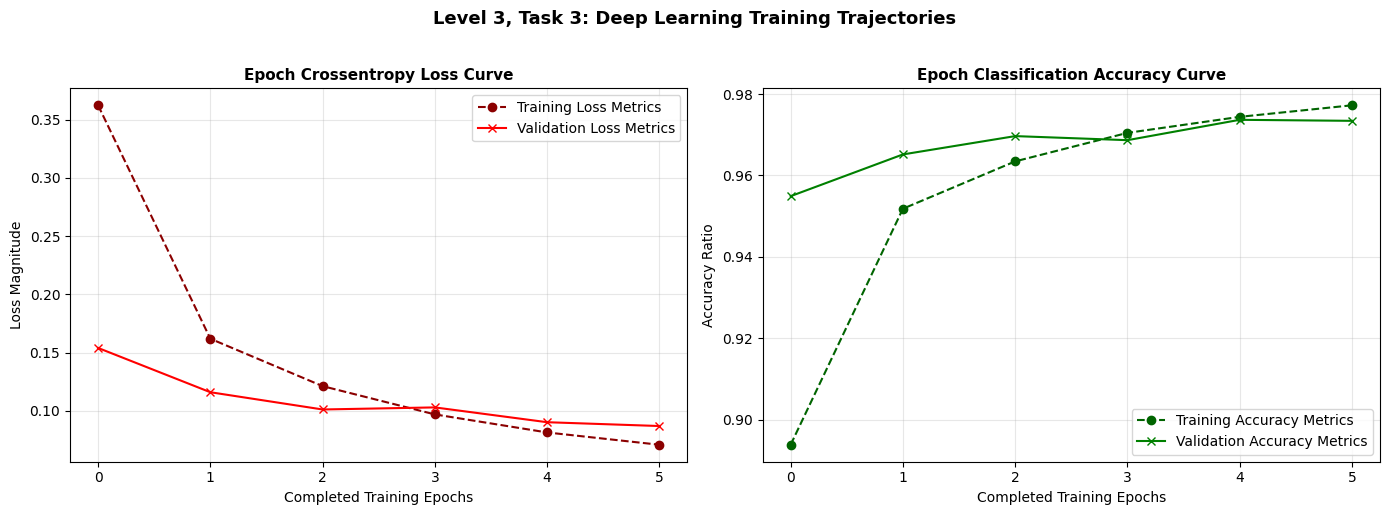

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist

# =====================================================================
# 1. DATA STREAMING & SCALING PREPROCESSING
# =====================================================================
print("⏳ Streaming and downloading the MNIST handwritten digit database...")
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f"✔️ Loaded {len(X_train_raw)} training images and {len(X_test_raw)} testing images.")
print(f"   -> Original image structural shape: {X_train_raw.shape[1:]} pixels")

# CRITICAL STEP: Normalize raw pixel intensities from [0, 255] down to [0.0, 1.0]
# This step keeps internal activations stable during gradient descent math.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# =====================================================================
# 2. STRUCTURAL ARCHITECTURE DESIGN
# =====================================================================
print("\n⚙️ Designing Multi-Layer Perceptron (MLP) Neural Network Blueprint...")

model = Sequential([
    # Input Layer: Flattens the 2D image matrix (28x28) into a 1D vector (784 features)
    Flatten(input_shape=(28, 28), name="Input_Flatten_784"),

    # Hidden Layer 1: 128 neurons utilizing ReLU to learn complex boundaries
    Dense(128, activation='relu', name="Hidden_Layer_1_ReLU"),

    # Regularization: Randomly silences 20% of nodes per batch to prevent overfitting
    Dropout(0.2, name="Regularization_Dropout_20pct"),

    # Hidden Layer 2: 64 neurons to specialize feature extraction maps
    Dense(64, activation='relu', name="Hidden_Layer_2_ReLU"),

    # Output Layer: 10 target nodes corresponding to digit probability arrays
    Dense(10, activation='softmax', name="Output_Probability_Softmax")
])

# Display a structural parameter breakdown in the terminal
model.summary()

# =====================================================================
# 3. COMPILATION & BACKPROPAGATION TRAINING
# =====================================================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Ideal for integer-encoded classification targets
    metrics=['accuracy']
)

print("\n🚀 Commencing model training and backpropagation tuning...")
# validation_split=0.2 pulls 20% of the training data aside to test the model's
# general performance after every single epoch iteration.
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=6,
    batch_size=64,
    verbose=1
)

# =====================================================================
# 4. HOLDOUT SYSTEM ACCURACY EVALUATION
# =====================================================================
print("\n🔒 Testing trained neural weights on completely unseen holdout data...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*50)
print("             NEURAL NETWORK FINAL SCORECARD")
print("="*50)
print(f" -> Final Out-of-Sample Test Accuracy : {test_accuracy * 100:.2f}%")
print(f" -> Final Calculated Test Loss Vector : {test_loss:.4f}")
print("="*50)

# =====================================================================
# 5. SYLLABUS LEARNING CURVE VISUALIZATION
# =====================================================================
print("\n📊 Generating Epoch Optimization Curve Plots...")

plt.figure(figsize=(14, 5))

# Plot 1: Loss Evaluation Trajectory
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss Metrics', color='darkred', linestyle='--', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss Metrics', color='red', marker='x')
plt.title('Epoch Crossentropy Loss Curve', fontsize=11, fontweight='bold')
plt.xlabel('Completed Training Epochs')
plt.ylabel('Loss Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy Evaluation Trajectory
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy Metrics', color='darkgreen', linestyle='--', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy Metrics', color='green', marker='x')
plt.title('Epoch Classification Accuracy Curve', fontsize=11, fontweight='bold')
plt.xlabel('Completed Training Epochs')
plt.ylabel('Accuracy Ratio')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("Level 3, Task 3: Deep Learning Training Trajectories", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()